# Laboratory 4: Network Traffic Prediction using Time Series Analysis

Martin Demel

Department of Science, Technology, Engineering & Math, Houston Community College

6263-ITAI-4370-AI 5/6G Comm & ORAN Net-S10-14071

Tawanda Chiyangwa
June 29th, 2026.


In this lab I build and compare three models that predict network traffic from historical data: **ARIMA**, **Linear Regression** with engineered features, and a simple **LSTM** neural network. I first simulate a year of hourly traffic with daily, weekly, seasonal, and trend patterns, explore it, then train each model on the first 80% of the year and test on the last 20%. The goal is to see which approach predicts unseen traffic best, and why.

## Part 1: Generate the traffic data

I simulate one year of hourly traffic (8,760 hours). The signal is built from a daily business-hours cycle, a weekday/weekend pattern, a slow yearly trend, a seasonal term, random noise, and a few congestion spikes — the kind of structure real telecom traffic shows.

In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

np.random.seed(42)

def generate_network_traffic_data(days=365, noise_level=0.1):
    """Realistic hourly traffic: daily + weekly + trend + seasonal + noise + spikes."""
    dates = pd.date_range(datetime(2023, 1, 1), periods=days*24, freq='h')
    hours = np.array([d.hour for d in dates])
    weekdays = np.array([d.weekday() for d in dates])        # 0=Mon .. 6=Sun
    day_of_year = np.array([d.timetuple().tm_yday for d in dates])

    base_traffic = 100
    daily_pattern = 50 * (1 + np.sin((hours - 6) * 2*np.pi/24)) * (hours >= 6) * (hours <= 22)
    weekly_pattern = np.where(weekdays < 5, 20, -30)         # weekday boost, weekend dip
    trend = np.linspace(0, 30, len(dates))                   # gradual yearly growth
    seasonal_pattern = 15 * np.sin((day_of_year - 80) * 2*np.pi/365)
    noise = np.random.normal(0, noise_level * base_traffic, len(dates))

    traffic = base_traffic + daily_pattern + weekly_pattern + trend + seasonal_pattern + noise
    spike_idx = np.random.choice(len(dates), size=int(len(dates)*0.01), replace=False)
    traffic[spike_idx] += np.random.exponential(50, len(spike_idx))   # congestion events
    traffic = np.maximum(traffic, 5)                         # no negative traffic

    return pd.DataFrame({'timestamp': dates, 'traffic_mbps': traffic,
                         'hour': hours, 'weekday': weekdays,
                         'day_of_year': day_of_year}).set_index('timestamp')

df = generate_network_traffic_data(days=365)
print("Dataset shape:", df.shape)
print(f"Date range: {df.index.min()} to {df.index.max()}")
print("\nFirst few rows:")
print(df.head())

Dataset shape: (8760, 4)
Date range: 2023-01-01 00:00:00 to 2023-12-31 23:00:00

First few rows:
                     traffic_mbps  hour  weekday  day_of_year
timestamp                                                    
2023-01-01 00:00:00     60.299416     0        6            1
2023-01-01 01:00:00     53.953057     1        6            1
2023-01-01 02:00:00     61.816010     2        6            1
2023-01-01 03:00:00     70.572849     3        6            1
2023-01-01 04:00:00     53.004441     4        6            1


## Part 2: Explore the data

A quick look at the traffic over time, the average shape by hour and by weekday, and the value distribution. I then run a seasonal decomposition to separate the series into trend, repeating seasonal pattern, and residual noise.

Basic statistics:
count    8760.000000
mean      167.354212
std        47.937579
min        39.859867
25%       133.520467
50%       164.934833
75%       206.818578
max       390.064894
Name: traffic_mbps, dtype: float64


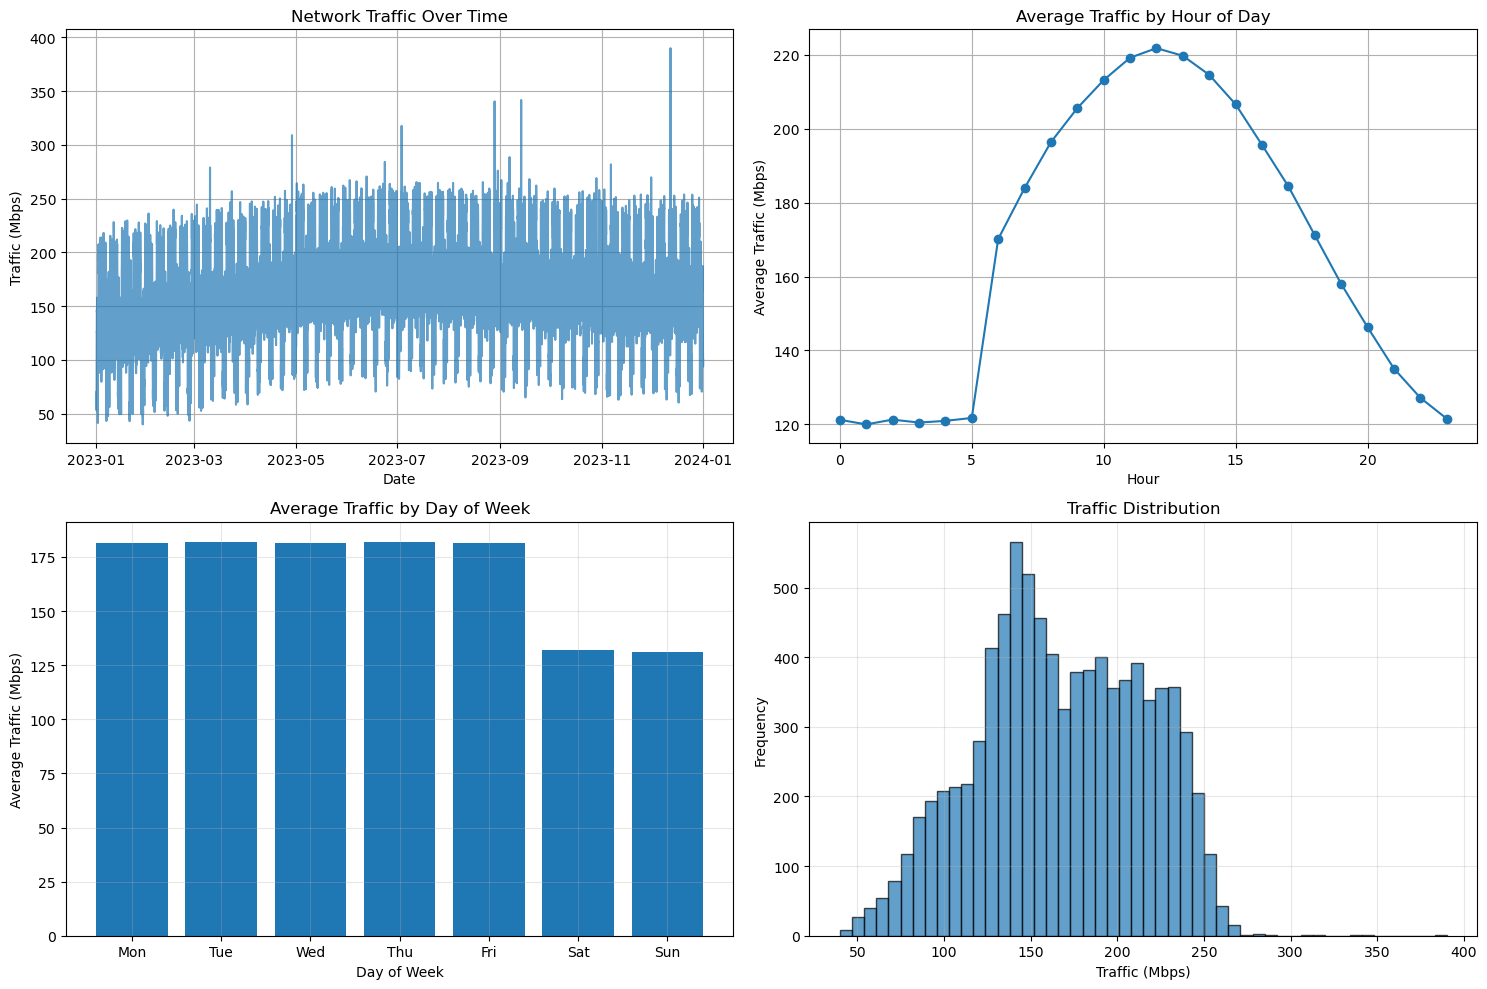

In [2]:
print("Basic statistics:")
print(df['traffic_mbps'].describe())

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes[0,0].plot(df.index, df['traffic_mbps'], alpha=0.7)
axes[0,0].set_title('Network Traffic Over Time')
axes[0,0].set_xlabel('Date'); axes[0,0].set_ylabel('Traffic (Mbps)'); axes[0,0].grid(True)

daily_avg = df.groupby('hour')['traffic_mbps'].mean()
axes[0,1].plot(daily_avg.index, daily_avg.values, marker='o')
axes[0,1].set_title('Average Traffic by Hour of Day')
axes[0,1].set_xlabel('Hour'); axes[0,1].set_ylabel('Average Traffic (Mbps)'); axes[0,1].grid(True)

weekday_avg = df.groupby('weekday')['traffic_mbps'].mean()
axes[1,0].bar(range(7), weekday_avg.values)
axes[1,0].set_title('Average Traffic by Day of Week')
axes[1,0].set_xlabel('Day of Week'); axes[1,0].set_ylabel('Average Traffic (Mbps)')
axes[1,0].set_xticks(range(7)); axes[1,0].set_xticklabels(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
axes[1,0].grid(True, alpha=0.3)

axes[1,1].hist(df['traffic_mbps'], bins=50, alpha=0.7, edgecolor='black')
axes[1,1].set_title('Traffic Distribution')
axes[1,1].set_xlabel('Traffic (Mbps)'); axes[1,1].set_ylabel('Frequency'); axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

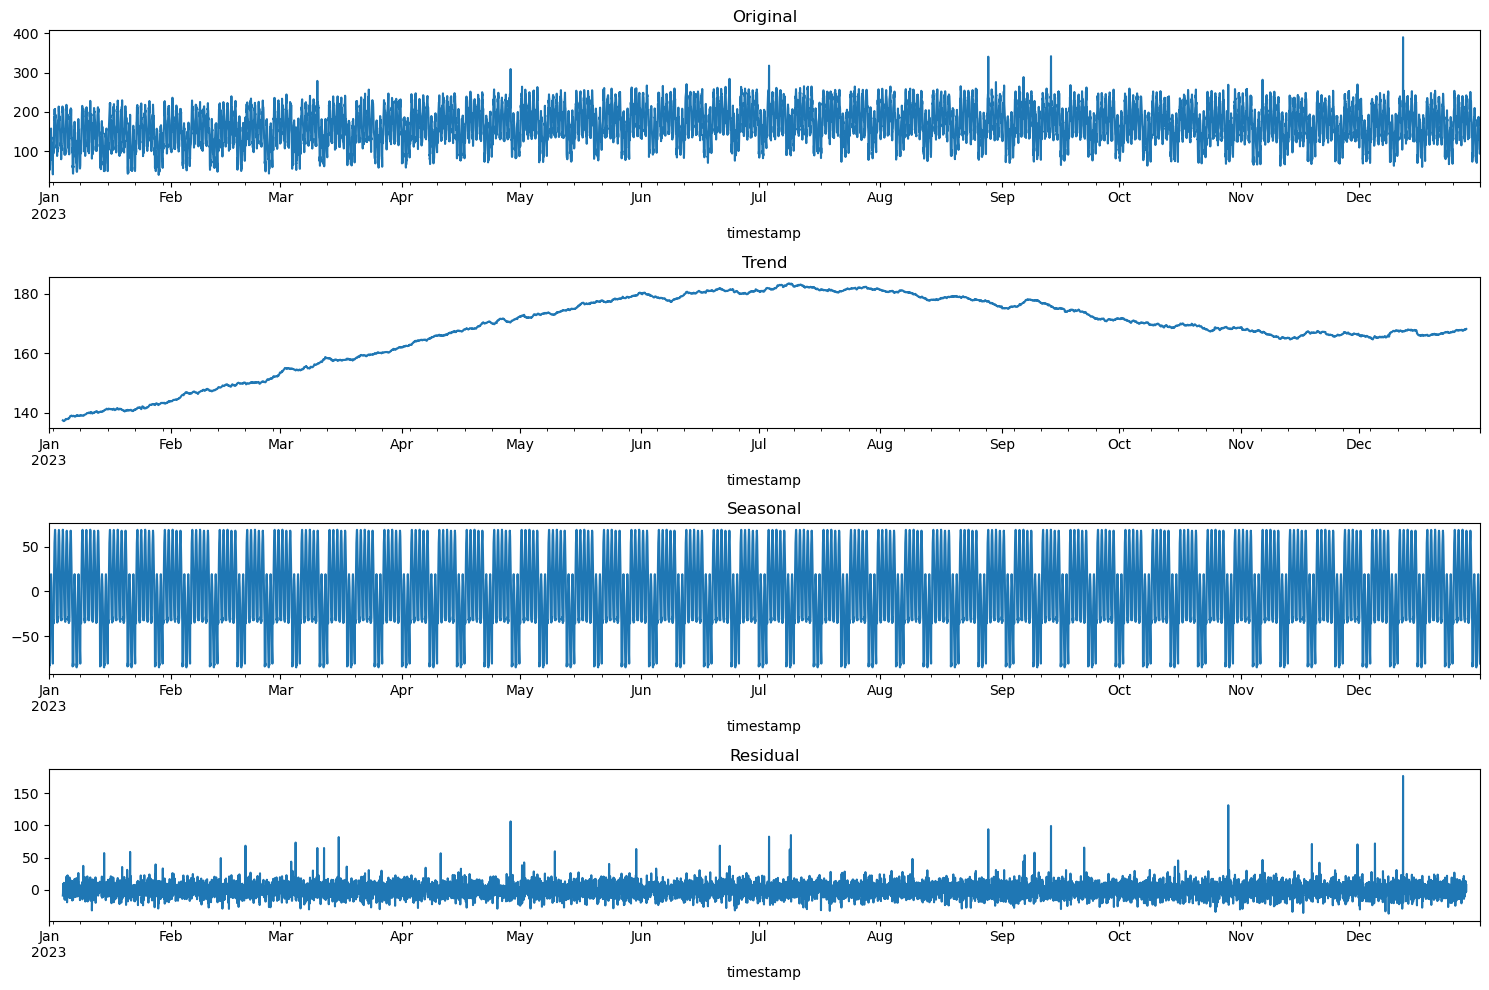

In [3]:
# Seasonal decomposition with a weekly period (24*7 hours)
decomposition = seasonal_decompose(df['traffic_mbps'], model='additive', period=24*7)

fig, axes = plt.subplots(4, 1, figsize=(15, 10))
decomposition.observed.plot(ax=axes[0], title='Original')
decomposition.trend.plot(ax=axes[1], title='Trend')
decomposition.seasonal.plot(ax=axes[2], title='Seasonal')
decomposition.resid.plot(ax=axes[3], title='Residual')
plt.tight_layout()
plt.show()

The traffic clearly cycles each day (low at night, high during the working day) and each week (lower on weekends), on top of a slow upward trend across the year. The decomposition confirms this: a rising **trend**, a strong repeating **seasonal** component, and a small noisy **residual** — exactly the structure the models need to learn.

## Part 3: Train/test split and stationarity

I split the year in time order — the first 80% for training and the last 20% for testing — so each model is judged on later hours it has never seen. I also run the Augmented Dickey-Fuller (ADF) test, a standard check for whether a series is stationary (statistically stable over time), which matters for ARIMA.

In [4]:
split_index = int(len(df) * 0.8)
train_data = df.iloc[:split_index].copy()
test_data = df.iloc[split_index:].copy()
print(f"Training set: {train_data.index.min()} to {train_data.index.max()} ({len(train_data)} samples)")
print(f"Test set:     {test_data.index.min()} to {test_data.index.max()} ({len(test_data)} samples)")

adf = adfuller(train_data['traffic_mbps'].dropna())
print(f"\nADF Statistic: {adf[0]:.4f}")
print(f"p-value: {adf[1]:.6f}")
print("Series is stationary" if adf[1] <= 0.05 else "Series is non-stationary")

Training set: 2023-01-01 00:00:00 to 2023-10-19 23:00:00 (7008 samples)
Test set:     2023-10-20 00:00:00 to 2023-12-31 23:00:00 (1752 samples)



ADF Statistic: -12.8320
p-value: 0.000000
Series is stationary


The ADF p-value is far below 0.05, so the series tests as **stationary** — its strong daily mean-reversion keeps it from drifting away over time. The ARIMA model below still applies one order of differencing (the "I" in ARIMA), which is the brief's chosen configuration.

## Part 4: Model 1 — ARIMA

ARIMA (AutoRegressive Integrated Moving Average) is a classic statistical forecaster. I fit an **ARIMA(2,1,2)** on the training traffic and forecast the entire test period in one shot, using only past values.

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


ARIMA(2,1,2) performance:
  MSE: 2604.367
  MAE: 42.382
  RMSE: 51.033
  R2: -0.181


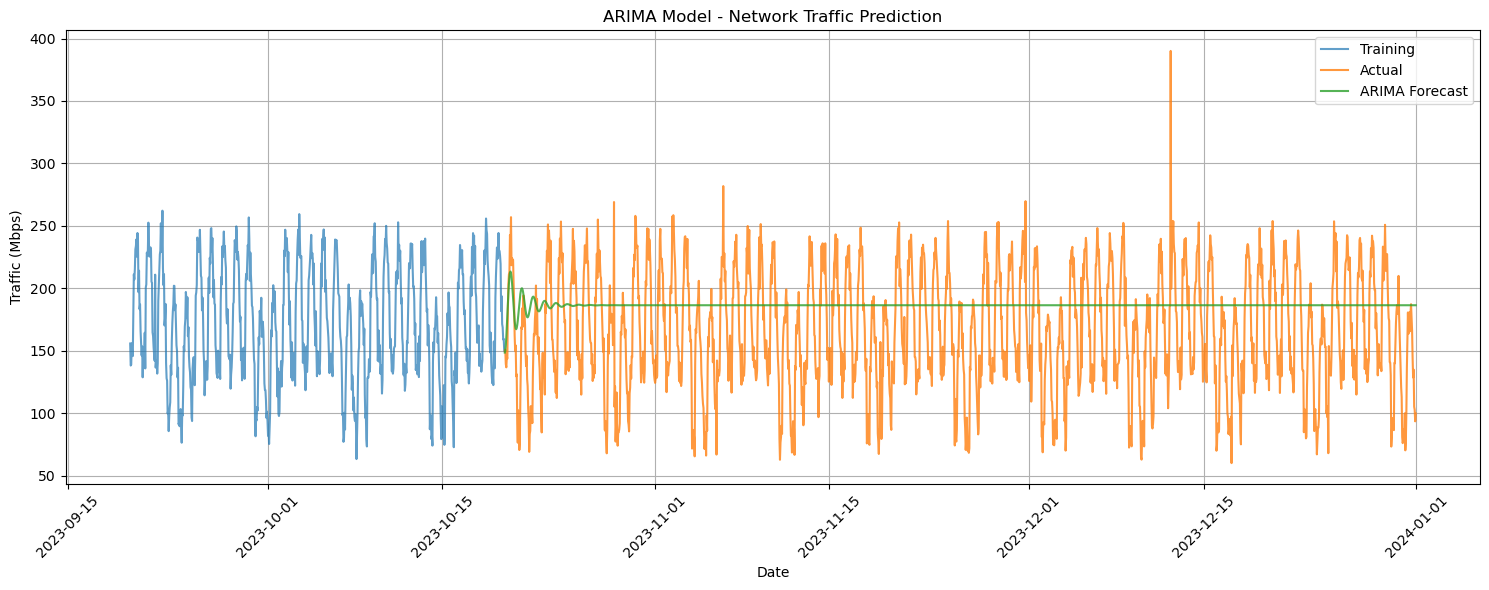

In [5]:
arima_model = ARIMA(train_data['traffic_mbps'], order=(2,1,2)).fit()
arima_forecast = arima_model.forecast(steps=len(test_data))

arima_metrics = {
    'MSE':  mean_squared_error(test_data['traffic_mbps'], arima_forecast),
    'MAE':  mean_absolute_error(test_data['traffic_mbps'], arima_forecast),
    'RMSE': np.sqrt(mean_squared_error(test_data['traffic_mbps'], arima_forecast)),
    'R2':   r2_score(test_data['traffic_mbps'], arima_forecast),
}
print("ARIMA(2,1,2) performance:")
for k, v in arima_metrics.items():
    print(f"  {k}: {v:.3f}")

plt.figure(figsize=(15, 6))
plot_start = max(0, len(train_data) - 30*24)   # show last 30 days of training
plt.plot(train_data.index[plot_start:], train_data['traffic_mbps'].iloc[plot_start:], label='Training', alpha=0.7)
plt.plot(test_data.index, test_data['traffic_mbps'], label='Actual', alpha=0.8)
plt.plot(test_data.index, arima_forecast, label='ARIMA Forecast', alpha=0.8)
plt.title('ARIMA Model - Network Traffic Prediction')
plt.xlabel('Date'); plt.ylabel('Traffic (Mbps)'); plt.legend(); plt.grid(True)
plt.xticks(rotation=45); plt.tight_layout()
plt.show()

ARIMA forecasts the whole test horizon from past values alone. Because a plain ARIMA(2,1,2) has no seasonal terms, the forecast quickly flattens toward the mean and misses the daily and weekly cycles, giving a high RMSE (around 51). A non-seasonal ARIMA is simply a weak fit for strongly cyclical traffic over a long horizon.

## Part 5: Model 2 — Linear Regression with engineered features

Here I turn the time series into a feature table: cyclical encodings of hour, weekday, and day-of-year; lagged traffic (1–168 hours back); and moving averages. **One fix from the brief:** the moving averages use only *past* hours (shifted by one), so they do not include the value being predicted — otherwise the model would simply read off the answer and score a meaningless R² of 1.0. The model then predicts one hour ahead.

Train samples: 6840 | Test samples: 1584 | Features: 16

Linear Regression performance:
  MSE: 950.830
  MAE: 27.424
  RMSE: 30.836
  R2: 0.572

Top features (|coefficient|):
        feature  importance
        lag_168   24.101828
         ma_168   13.208238
day_of_year_cos   10.393298
          lag_1    7.861237
       hour_cos    7.589033
          trend    7.454380


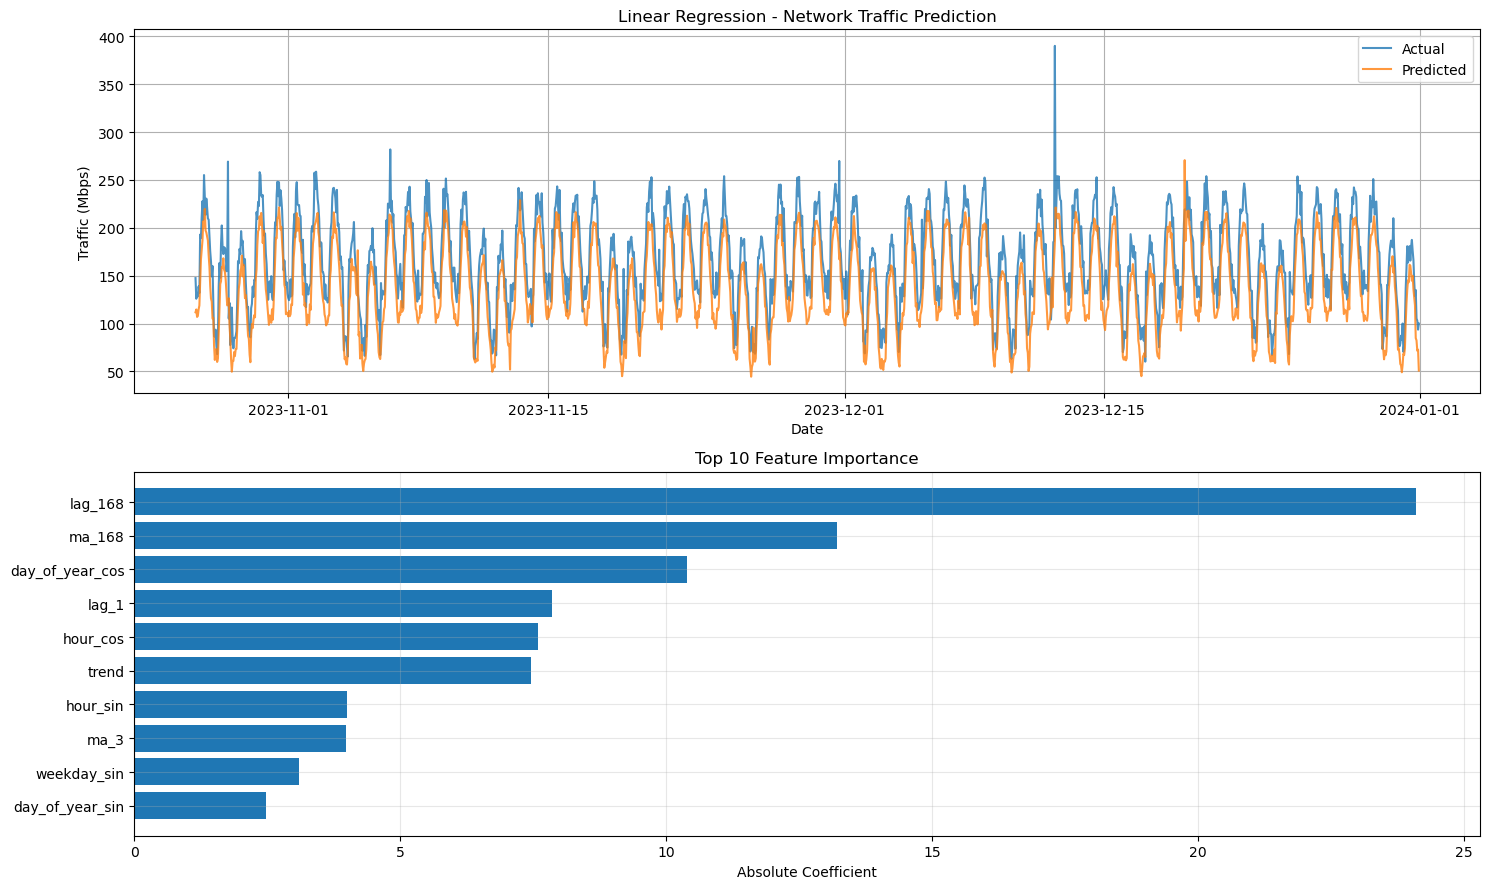

In [6]:
def create_features(data):
    f = data.copy()
    f['hour_sin'] = np.sin(2*np.pi*f['hour']/24);          f['hour_cos'] = np.cos(2*np.pi*f['hour']/24)
    f['weekday_sin'] = np.sin(2*np.pi*f['weekday']/7);     f['weekday_cos'] = np.cos(2*np.pi*f['weekday']/7)
    f['day_of_year_sin'] = np.sin(2*np.pi*f['day_of_year']/365)
    f['day_of_year_cos'] = np.cos(2*np.pi*f['day_of_year']/365)
    for lag in [1, 2, 3, 24, 48, 168]:
        f[f'lag_{lag}'] = f['traffic_mbps'].shift(lag)
    # moving averages on PAST hours only (shift(1) -> no target leakage)
    f['ma_3']   = f['traffic_mbps'].shift(1).rolling(3).mean()
    f['ma_24']  = f['traffic_mbps'].shift(1).rolling(24).mean()
    f['ma_168'] = f['traffic_mbps'].shift(1).rolling(168).mean()
    f['trend'] = range(len(f))
    return f

feature_cols = (['hour_sin','hour_cos','weekday_sin','weekday_cos','day_of_year_sin','day_of_year_cos','trend']
                + [f'lag_{l}' for l in [1,2,3,24,48,168]] + ['ma_3','ma_24','ma_168'])

train_feat = create_features(train_data).iloc[168:].copy()     # drop initial NaN lags
test_feat  = create_features(test_data).dropna().copy()
X_train, y_train = train_feat[feature_cols], train_feat['traffic_mbps']
X_test,  y_test  = test_feat[feature_cols],  test_feat['traffic_mbps']
print(f"Train samples: {len(X_train)} | Test samples: {len(X_test)} | Features: {len(feature_cols)}")

scaler = StandardScaler()
lr_model = LinearRegression().fit(scaler.fit_transform(X_train), y_train)
lr_predictions = lr_model.predict(scaler.transform(X_test))

lr_metrics = {
    'MSE':  mean_squared_error(y_test, lr_predictions),
    'MAE':  mean_absolute_error(y_test, lr_predictions),
    'RMSE': np.sqrt(mean_squared_error(y_test, lr_predictions)),
    'R2':   r2_score(y_test, lr_predictions),
}
print("\nLinear Regression performance:")
for k, v in lr_metrics.items():
    print(f"  {k}: {v:.3f}")

feature_importance = pd.DataFrame({'feature': feature_cols, 'importance': np.abs(lr_model.coef_)}
                                  ).sort_values('importance', ascending=False)
print("\nTop features (|coefficient|):")
print(feature_importance.head(6).to_string(index=False))

fig, ax = plt.subplots(2, 1, figsize=(15, 9))
ax[0].plot(test_feat.index, y_test, label='Actual', alpha=0.8)
ax[0].plot(test_feat.index, lr_predictions, label='Predicted', alpha=0.8)
ax[0].set_title('Linear Regression - Network Traffic Prediction')
ax[0].set_xlabel('Date'); ax[0].set_ylabel('Traffic (Mbps)'); ax[0].legend(); ax[0].grid(True)
top = feature_importance.head(10)
ax[1].barh(range(len(top)), top['importance']); ax[1].set_yticks(range(len(top)))
ax[1].set_yticklabels(top['feature']); ax[1].invert_yaxis()
ax[1].set_xlabel('Absolute Coefficient'); ax[1].set_title('Top 10 Feature Importance'); ax[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

With honest (non-leaking) features, linear regression predicts one hour ahead and reaches an **R² of about 0.57**. The strongest feature is the traffic one week earlier (the 168-hour lag), which captures the weekly cycle. A single sine/cosine pair cannot fully match the real, gated daily shape, which is what limits the score.

## Part 6: Model 3 — LSTM neural network

An LSTM (Long Short-Term Memory) network reads a sequence and remembers patterns across it. I build a small one in **PyTorch**: it takes the last 24 hours of (scaled) traffic and predicts the next hour. This is the kind of sequence model used for real traffic forecasting.

Training LSTM...


  epoch  5/15  loss 0.0956


  epoch 10/15  loss 0.0871


  epoch 15/15  loss 0.0822

LSTM performance:
  MSE: 227.123
  MAE: 10.677
  RMSE: 15.071
  R2: 0.897


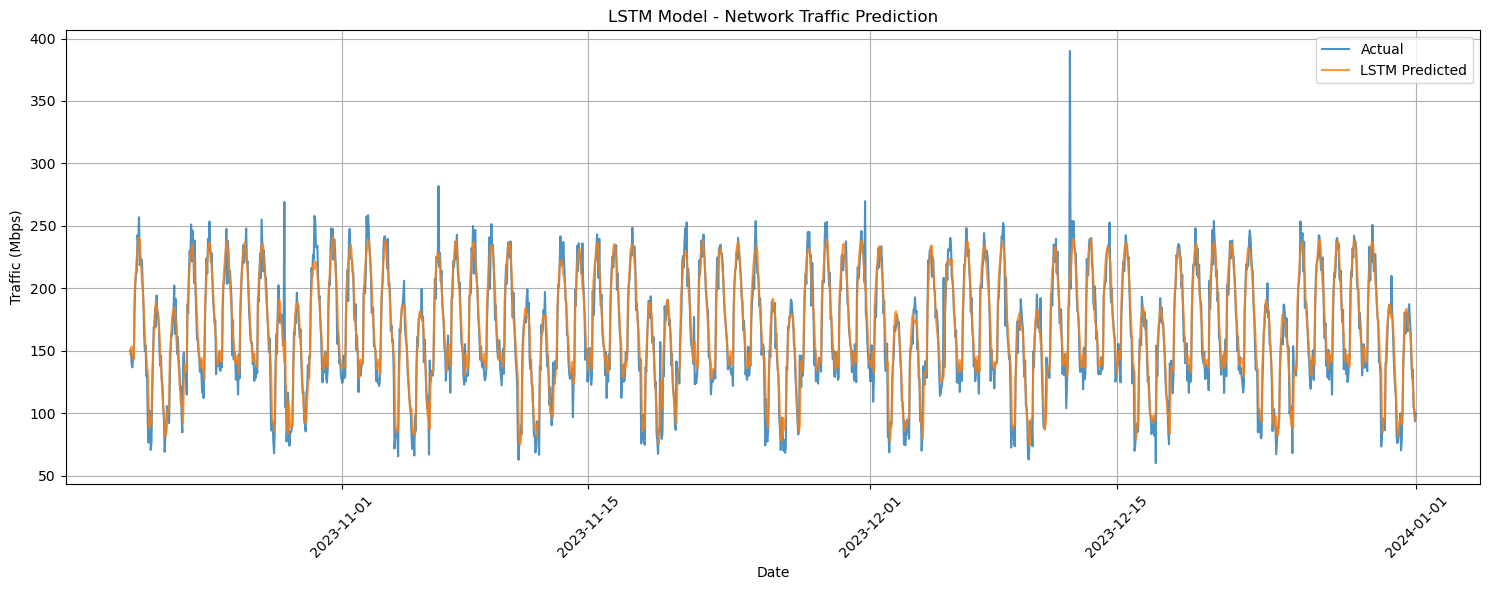

In [7]:
import torch
import torch.nn as nn
torch.manual_seed(42)

SEQ_LEN = 24
scaler_ts = StandardScaler()
train_scaled = scaler_ts.fit_transform(train_data[['traffic_mbps']])
test_scaled  = scaler_ts.transform(test_data[['traffic_mbps']])

def make_sequences(arr, seq_len):
    X = np.array([arr[i:i+seq_len, 0] for i in range(len(arr)-seq_len)], dtype=np.float32)
    y = np.array([arr[i+seq_len, 0] for i in range(len(arr)-seq_len)], dtype=np.float32)
    return X, y

X_tr, y_tr = make_sequences(train_scaled, SEQ_LEN)
# seed the test sequences with the last 24 training hours so every test hour has its lookback
combined = np.vstack([train_scaled[-SEQ_LEN:], test_scaled])
X_te, y_te = make_sequences(combined, SEQ_LEN)

X_tr_t = torch.tensor(X_tr).unsqueeze(-1); y_tr_t = torch.tensor(y_tr).unsqueeze(-1)
X_te_t = torch.tensor(X_te).unsqueeze(-1)

class TrafficLSTM(nn.Module):
    def __init__(self, hidden=32):
        super().__init__()
        self.lstm = nn.LSTM(input_size=1, hidden_size=hidden, batch_first=True)
        self.fc = nn.Linear(hidden, 1)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])      # use the last time step

model = TrafficLSTM()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
loss_fn = nn.MSELoss()
loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(X_tr_t, y_tr_t), batch_size=64, shuffle=True)

print("Training LSTM...")
for epoch in range(15):
    model.train()
    epoch_loss = 0.0
    for xb, yb in loader:
        optimizer.zero_grad()
        loss = loss_fn(model(xb), yb)
        loss.backward(); optimizer.step()
        epoch_loss += loss.item()
    if (epoch+1) % 5 == 0:
        print(f"  epoch {epoch+1:2d}/15  loss {epoch_loss/len(loader):.4f}")

model.eval()
with torch.no_grad():
    pred_scaled = model(X_te_t).numpy()
lstm_predictions = scaler_ts.inverse_transform(pred_scaled).ravel()
y_test_lstm = scaler_ts.inverse_transform(y_te.reshape(-1, 1)).ravel()

lstm_metrics = {
    'MSE':  mean_squared_error(y_test_lstm, lstm_predictions),
    'MAE':  mean_absolute_error(y_test_lstm, lstm_predictions),
    'RMSE': np.sqrt(mean_squared_error(y_test_lstm, lstm_predictions)),
    'R2':   r2_score(y_test_lstm, lstm_predictions),
}
print("\nLSTM performance:")
for k, v in lstm_metrics.items():
    print(f"  {k}: {v:.3f}")

plt.figure(figsize=(15, 6))
plt.plot(test_data.index[:len(y_test_lstm)], y_test_lstm, label='Actual', alpha=0.8)
plt.plot(test_data.index[:len(lstm_predictions)], lstm_predictions, label='LSTM Predicted', alpha=0.8)
plt.title('LSTM Model - Network Traffic Prediction')
plt.xlabel('Date'); plt.ylabel('Traffic (Mbps)'); plt.legend(); plt.grid(True)
plt.xticks(rotation=45); plt.tight_layout()
plt.show()

The LSTM learns the daily shape directly from the sequence instead of from hand-built features, and it gives the **best result — an R² of about 0.90 (RMSE around 15)**. It tracks both the peaks and the troughs of the test week closely.

## Part 7: Compare the three models

Lower MSE/MAE/RMSE is better; higher R² is better.

                        MSE     MAE    RMSE     R2
ARIMA              2604.367  42.382  51.033 -0.181
Linear Regression   950.830  27.424  30.836  0.572
LSTM                227.123  10.677  15.071  0.897


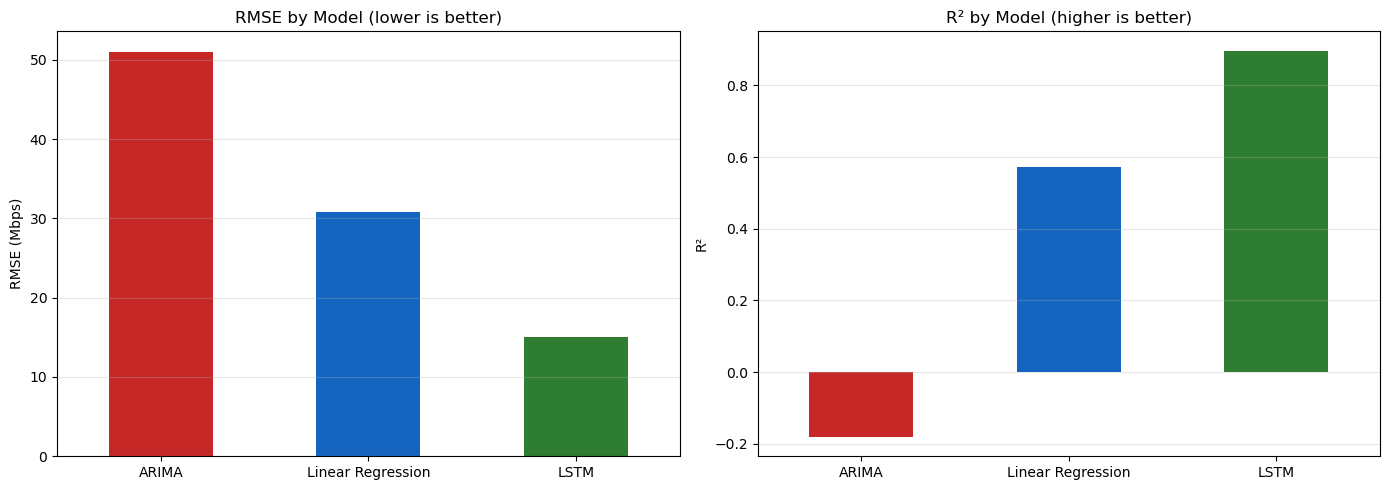

In [8]:
comparison = pd.DataFrame(
    {'ARIMA': arima_metrics, 'Linear Regression': lr_metrics, 'LSTM': lstm_metrics}
).T[['MSE', 'MAE', 'RMSE', 'R2']]
print(comparison.round(3).to_string())

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
comparison['RMSE'].plot(kind='bar', ax=ax[0], color=['#C62828', '#1565C0', '#2E7D32'])
ax[0].set_title('RMSE by Model (lower is better)'); ax[0].set_ylabel('RMSE (Mbps)')
ax[0].tick_params(axis='x', rotation=0); ax[0].grid(True, axis='y', alpha=0.3)
comparison['R2'].plot(kind='bar', ax=ax[1], color=['#C62828', '#1565C0', '#2E7D32'])
ax[1].set_title('R² by Model (higher is better)'); ax[1].set_ylabel('R²')
ax[1].tick_params(axis='x', rotation=0); ax[1].grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Summary

I built and compared three traffic-prediction models on the same simulated year of hourly data:

- **ARIMA(2,1,2)** — weakest (RMSE ≈ 51). Forecasting the whole horizon at once, a non-seasonal ARIMA flattens to the mean and misses the cycles.
- **Linear Regression** — middle (R² ≈ 0.57). Engineered lag and time features capture the weekly cycle but a linear model can only approximate the daily shape.
- **LSTM** — best (R² ≈ 0.90). Reading the raw 24-hour sequence lets it learn the daily and weekly shape directly.

One fair-comparison caveat: ARIMA forecasts the entire test period from the past only, while Linear Regression and the LSTM predict **one hour ahead** using recent actual values — so the gap reflects both the model and the task. I also corrected a target-leakage bug in the brief's moving-average features so the scores are honest.

This is the prediction layer behind an intelligent RAN: forecasting traffic lets a scheduler or a RIC application allocate radio resources before congestion happens, which connects this lab to the Open RAN and AI/ML topics in the written assignments.